First 5 rows:
   Year    Term  Applications  Admitted  Enrolled  Retention Rate (%)  \
0  2015  Spring          2500      1500       600                  85   
1  2015    Fall          2500      1500       600                  85   
2  2016  Spring          2600      1550       625                  86   
3  2016    Fall          2600      1550       625                  86   
4  2017  Spring          2700      1600       650                  87   

   Student Satisfaction (%)  Engineering Enrolled  Business Enrolled  \
0                        78                   200                150   
1                        78                   200                150   
2                        79                   210                160   
3                        79                   210                160   
4                        80                   225                165   

   Arts Enrolled  Science Enrolled  
0            125               125  
1            125               125  
2  

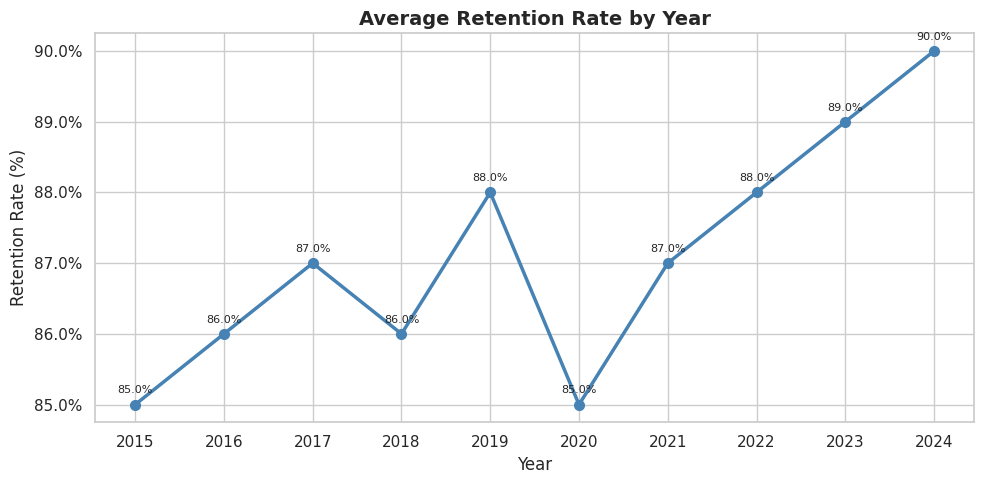

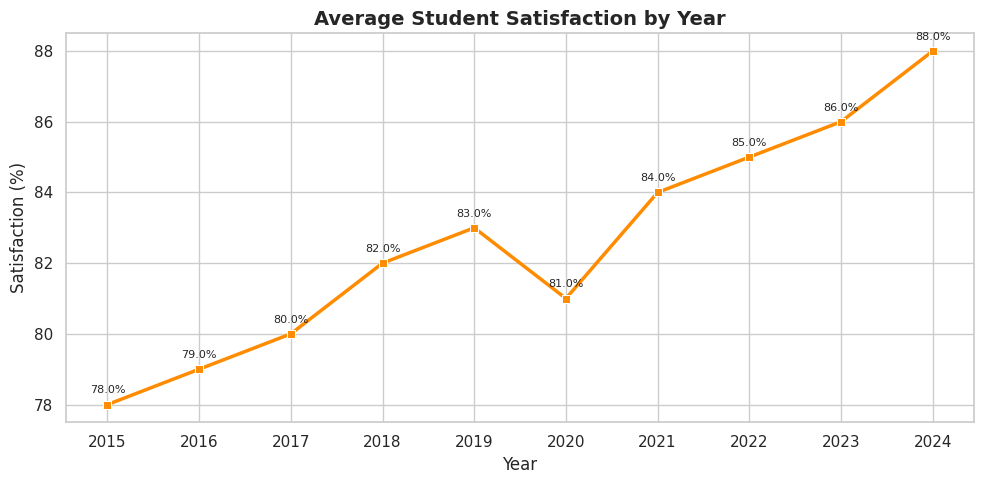

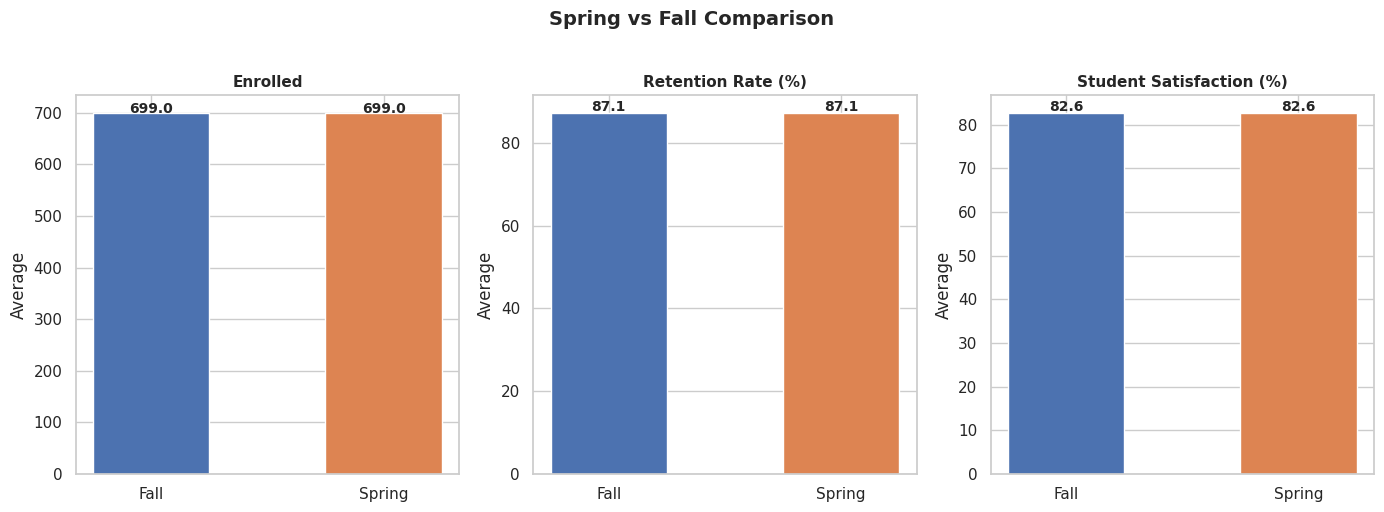

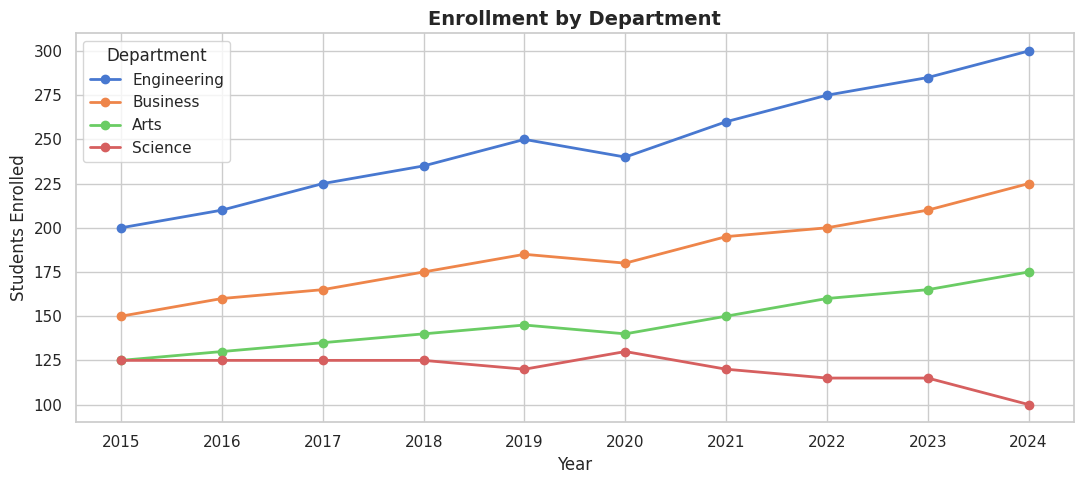

In [1]:
# Activity 1 - Data Mining
# Universidad de la Costa
# Camilo Andres Visbal Beltran

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load dataset
URL = "https://raw.githubusercontent.com/camilovisbal/dashboard-universitario/main/university_student_data.csv"
df = pd.read_csv(URL)

# initial exploration
print("First 5 rows:")
print(df.head())

print("\nDataset dimensions:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
print(df.describe())

print("\nNull values:")
print(df.isnull().sum())

print("\nAvailable years:")
print(sorted(df['Year'].unique()))

print("\nAvailable terms:")
print(df['Term'].unique())

# column descriptions
print("\nColumn descriptions:")
print("Year: academic year of the record")
print("Term: semester Spring or Fall")
print("Applications: total students who applied")
print("Admitted: total students admitted")
print("Enrolled: total students enrolled")
print("Retention Rate (%): percentage of students who continued the following semester")
print("Student Satisfaction (%): average satisfaction percentage")
print("Engineering Enrolled: students enrolled in Engineering")
print("Business Enrolled: students enrolled in Business")
print("Arts Enrolled: students enrolled in Arts")
print("Science Enrolled: students enrolled in Science")

sns.set_theme(style="whitegrid", palette="muted")

# retention rate by year
retention_by_year = df.groupby('Year')['Retention Rate (%)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(retention_by_year['Year'], retention_by_year['Retention Rate (%)'],
        marker='o', linewidth=2.5, color='steelblue', markersize=7)
ax.set_title("Average Retention Rate by Year", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Retention Rate (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xticks(retention_by_year['Year'])
for x, y in zip(retention_by_year['Year'], retention_by_year['Retention Rate (%)']):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig("retention_by_year.png", dpi=150)
plt.show()

# student satisfaction by year
satisfaction_by_year = df.groupby('Year')['Student Satisfaction (%)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=satisfaction_by_year, x='Year', y='Student Satisfaction (%)',
             marker='s', linewidth=2.5, color='darkorange', ax=ax)
ax.set_title("Average Student Satisfaction by Year", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Satisfaction (%)")
ax.set_xticks(satisfaction_by_year['Year'])
for x, y in zip(satisfaction_by_year['Year'], satisfaction_by_year['Student Satisfaction (%)']):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig("satisfaction_by_year.png", dpi=150)
plt.show()

# spring vs fall comparison
comparison = df.groupby('Term')[['Enrolled', 'Retention Rate (%)', 'Student Satisfaction (%)']].mean().reset_index()

metrics = ['Enrolled', 'Retention Rate (%)', 'Student Satisfaction (%)']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452']

for i, metric in enumerate(metrics):
    axes[i].bar(comparison['Term'], comparison[metric], color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Average")
    for j, val in enumerate(comparison[metric]):
        axes[i].text(j, val + 0.5, f"{val:.1f}", ha='center', fontsize=10, fontweight='bold')

fig.suptitle("Spring vs Fall Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("spring_vs_fall.png", dpi=150)
plt.show()

# enrollment by department
departments = ['Engineering Enrolled', 'Business Enrolled', 'Arts Enrolled', 'Science Enrolled']
dept_by_year = df.groupby('Year')[departments].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for col in departments:
    ax.plot(dept_by_year['Year'], dept_by_year[col], marker='o', linewidth=2, label=col.replace(' Enrolled', ''))
ax.set_title("Enrollment by Department", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Students Enrolled")
ax.set_xticks(dept_by_year['Year'])
ax.legend(title="Department")
plt.tight_layout()
plt.savefig("enrollment_by_department.png", dpi=150)
plt.show()
